In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp "/content/drive/MyDrive/ML2.0_2025/Class_code_batch_2/pca_2d_data.csv" ./

In [ ]:
data = pd.read_csv('pca_2d_data.csv')
data.head()

,f1,f2
0,2.038772,1.102760
1,0.869536,0.238030
2,1.795888,1.020364
3,0.103510,-0.513661
4,1.479554,0.750702


<Axes: xlabel='f1', ylabel='f2'>

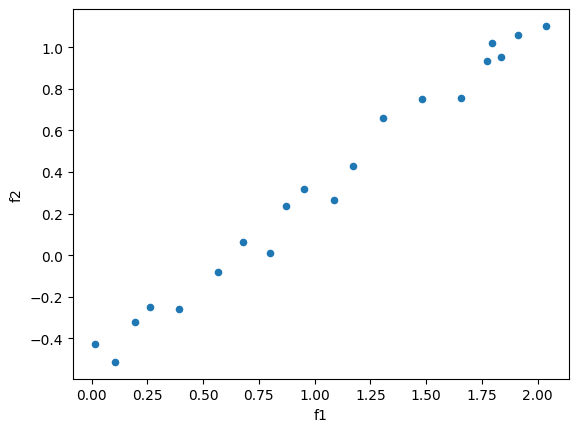

In [ ]:
data.plot(x='f1', y='f2', kind='scatter')

# Scratch Implementation:

In [ ]:

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # Mean centering
        self.mean = np.mean(X, axis=0)
        X = X - self.mean

        # covariance, function needs samples as columns
        cov = np.cov(X.T)

        # eigenvalues, eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov)


        #Sort eigen vector w.r.t eigen value
        eigenvectors = eigenvectors.T
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]
        print("Total Eigen_value", eigenvalues)
        print("Total Eigen_vector ",eigenvectors)

        print("Eigen_value", eigenvalues[0 : self.n_components])
        print("Eigen_vector ",eigenvectors[0 : self.n_components,:])
        # store first n eigenvectors
        self.components = eigenvectors[0 : self.n_components]

    def transform(self, X):
        # project data
        X = X - self.mean
        return np.dot(X, self.components.T)

In [ ]:
X = data.values

In [ ]:
pca = PCA(1)
pca.fit(X)
X_projected = pca.transform(X)

Total Eigen_value [0.72708225 0.00269373]
Total Eigen_vector  [[ 0.77314321  0.63423148]
 [-0.63423148  0.77314321]]
Eigen_value [0.72708225]
Eigen_vector  [[0.77314321 0.63423148]]


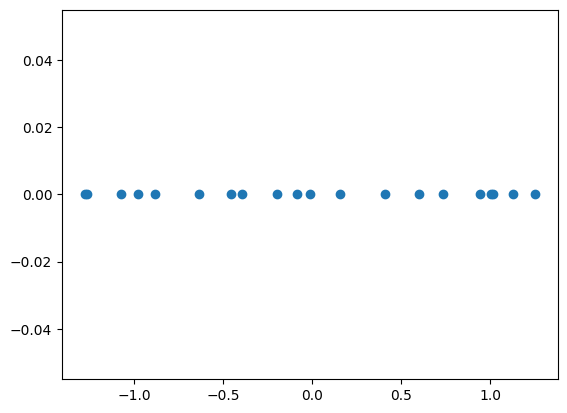

In [ ]:
# Visualise
plt.figure()
plt.scatter(X_projected, np.zeros((len(X_projected),)))
plt.show()

(20, 1)


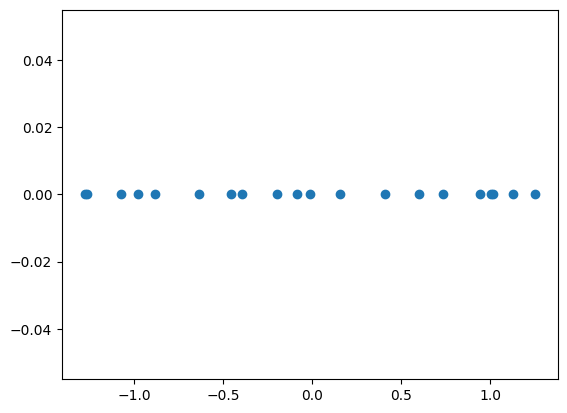

In [ ]:
from sklearn.decomposition import PCA
data_sc = data -data.mean(axis=0)
model = PCA(n_components=1)
X_p = model.fit_transform(data_sc)
print(X_p.shape)
plt.figure()
plt.scatter(X_p, np.zeros((len(data_sc),)))
plt.show()

In [ ]:
# Eigen value
model.explained_variance_

array([0.72708225])

In [ ]:
#Eigen vector
model.components_

array([[0.77314321, 0.63423148]])

In [ ]:
model.explained_variance_ratio_

array([0.99630883])